### Global Perturbation analysis and Selection Cut Optimization

#### In this section, we compile all perturbed datasets into a unified framework to evaluate the classifier's stability under unknown data sets. We demonstrate that when the trained model encounters an out-of-distribution tracking environment, the most effective first-order corrective action to maintain a our 99% background rejection figure-of-merit is to dynamically adapt the BDT selection threshold. By adjusting this cut value, we successfully absorb systematic distortions, preserve baseline signal selection efficiencies, and prevent background leakage.


In [2]:
import uproot
import pandas as pd
import numpy as np
import joblib
import json
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

In [3]:
# 1. Clear Master Paths & Configuration Constants
MODEL_PATH = "/Users/malikfarouh/Documents/ML_workspace/model/TrkQual_BDT1_v2.0.json"
BASE_PATH   = "/Users/malikfarouh/Documents/ML_workspace/data/trkqual_tree_v2.0_training.root"
TREE_NAME   = "trkqualtree"
TRKQUAL_CUT = 0.92

# Load the optimal model configuration cleanly from your laptop
#model = joblib.load(MODEL_PATH)

model = xgb.XGBClassifier()
model.load_model(MODEL_PATH)

# 2. Extract baseline arrays and build your length-locked evaluation matrix
print("Extracting baseline arrays and establishing length-locked environment...")
with uproot.open(f"{BASE_PATH}:{TREE_NAME}") as tree:
    arrays = tree.arrays(library="np")
    
    # Calculate master momentum resolutions natively for masking
    mom_ent = np.sqrt(arrays['trk_ent.mom.fCoordinates.fX']**2 + arrays['trk_ent.mom.fCoordinates.fY']**2 + arrays['trk_ent.mom.fCoordinates.fZ']**2)
    mom_mc  = np.sqrt(arrays['trk_ent_mc.mom.fCoordinates.fX']**2 + arrays['trk_ent_mc.mom.fCoordinates.fY']**2 + arrays['trk_ent_mc.mom.fCoordinates.fZ']**2)
    mom_res = mom_ent - mom_mc
    
    # Apply standard quality track filters to lock the 317,440 shape
    mask = ((mom_res > -0.25) & (mom_res < 0.25)) | (mom_res > 0.7)  

    # Store clean, filtered ground truth labels
    y_full_filtered = np.zeros(len(mom_res[mask]))
    y_full_filtered[(mom_res[mask] > -0.25) & (mom_res[mask] < 0.25)] = 1
    
    # Extract baseline baseline features
    nactive_base = arrays['trk.nactive'][mask]
    nhits_base   = arrays['trk.nhits'][mask]
    t0err_base   = arrays['trk_ent_pars.t0err'][mask]
    fitcon_base  = arrays['trk.fitcon'][mask]
    momerr_base  = arrays['trk_ent.momerr'][mask]
    nnull_base   = arrays['trk.nnullambig'][mask]
    nmat_base    = arrays['trk.nmatactive'][mask]

def evaluate_perturbed_stream(nactive, momerr):
    """Stacks modified tracking variables and returns aligned predictions."""
    nactive = np.asarray(nactive, dtype=float)
    momerr  = np.asarray(momerr, dtype=float)

    factive = np.divide(nactive, nhits_base, out=np.zeros_like(nactive, dtype=float), where=nhits_base!=0)
    fambig  = np.divide(nnull_base, nactive, out=np.zeros_like(nactive, dtype=float), where=nactive!=0)
    fstraws = np.divide(nmat_base, nactive, out=np.zeros_like(nactive, dtype=float), where=nactive!=0)

    x = np.vstack((nactive, factive, t0err_base, fambig, fitcon_base, momerr, fstraws)).T
    return model.predict_proba(x)[:, 1]

# 3. Generate All Environment Streams from the SAME baseline track indices
print("Generating model predictions across all study environments...")
y_pred_orig           = evaluate_perturbed_stream(nactive_base,     momerr_base)
y_pred_perturbed_full = evaluate_perturbed_stream(nactive_base + 1, momerr_base)
y_pred_up             = evaluate_perturbed_stream(nactive_base,     momerr_base * 1.10)
y_pred_down           = evaluate_perturbed_stream(nactive_base,     momerr_base * 0.90)
y_pred_up50           = evaluate_perturbed_stream(nactive_base,     momerr_base * 1.50)
y_pred_down50         = evaluate_perturbed_stream(nactive_base,     momerr_base * 0.50)

print(f"Stored 6 environment prediction layers with matching shapes: {y_pred_orig.shape}")

Extracting baseline arrays and establishing length-locked environment...
Generating model predictions across all study environments...
Stored 6 environment prediction layers with matching shapes: (317440,)


In [7]:
print(len(y_full_filtered))
print(N_signal)

317440
303991


In [8]:
# 1. Verification Diagnostics Printout
N_signal = (y_full_filtered == 1).sum()
print(f"Note: % calculated over total # tracks (N={len(y_full_filtered):,})")
print("This is appropriate as the dataset is predominantly signal-like (CE electrons)\n")

print(f"{'Dataset':<25s} {'AUC':>8s} {'Signal eff':>12s} {'BDT cut':>10s} {'Mean shift':>12s} {'% of signal':>12s} {'Signal':>8s} {'Bkg':>6s}")
print("-" * 105)


all_studies = [
    ('Original',     y_pred_orig),
    #('nactive +1',   y_pred_perturbed_full), 
    ('momerr +10%',  y_pred_up),
    ('momerr -10%',  y_pred_down),
    ('momerr +50%',  y_pred_up50),
    ('momerr -50%',  y_pred_down50),
]

optimal_cuts = {}

for label, scores in all_studies:
    # Build ROC configurations cleanly with matching dimensions
    fpr, tpr, thresholds = roc_curve(y_full_filtered, scores, pos_label=1)
    auc_score = auc(fpr, tpr)

    idx = np.where(1 - fpr >= 0.99)[0]
    cut_idx = idx[-1] if idx.size > 0 else 0

    sig_eff = tpr[cut_idx]
    opt_cut = thresholds[cut_idx] 
    optimal_cuts[label] = opt_cut
    
    delta = scores - y_pred_orig
    
    # Evaluate track pass status shifts using your baseline threshold
    bdt_pass_orig = y_pred_orig >= TRKQUAL_CUT
    bdt_pass_new  = scores >= opt_cut
    
    changed = (bdt_pass_orig != bdt_pass_new).sum()
    drift_mask = bdt_pass_orig != bdt_pass_new
    
    sig_changed = ((drift_mask) & (y_full_filtered == 1)).sum()
    bkg_changed = ((drift_mask) & (y_full_filtered == 0)).sum()
    pct_signal = (sig_changed / N_signal) * 100
    #pct_signal = (sig_changed / len(y_full_filtered)) * 100
    
    if label == 'Original':
        print(f"{'Original':<25s} {auc_score:>8.4f} {sig_eff*100:>11.2f}% {opt_cut:>10.4f}")
        print(f"{'-'*12:>25s} {'-'*8:>12s} {'-'*6:>8s}")
    else:
        print(f"{label:<25} {auc_score:>8.4f} {sig_eff:>10.2f}% {opt_cut:>10.4f} "
              f"{delta.mean():>12.6f} {pct_signal:>12.2f}% {sig_changed:>8,} {bkg_changed:>6,}")

print()
print("Optimal BDT cuts saved for momentum distribution plots:")
for label, cut in optimal_cuts.items():
    print(f"  → {label:<25s} cut = {cut:.4f}")

Note: % calculated over total # tracks (N=317,440)
This is appropriate as the dataset is predominantly signal-like (CE electrons)

Dataset                        AUC   Signal eff    BDT cut   Mean shift  % of signal   Signal    Bkg
---------------------------------------------------------------------------------------------------------
Original                    0.9486       57.25%     0.9202
             ------------     --------   ------
momerr +10%                 0.9482       0.56%     0.9044    -0.024256         2.52%    7,674     23
momerr -10%                 0.9484       0.57%     0.9402     0.024102         2.56%    7,775     27
momerr +50%                 0.9467       0.55%     0.7905    -0.119494         4.30%   13,057     37
momerr -50%                 0.9459       0.55%     0.9810     0.111952         5.84%   17,747     47

Optimal BDT cuts saved for momentum distribution plots:
  → Original                  cut = 0.9202
  → momerr +10%               cut = 0.9044
  → mome

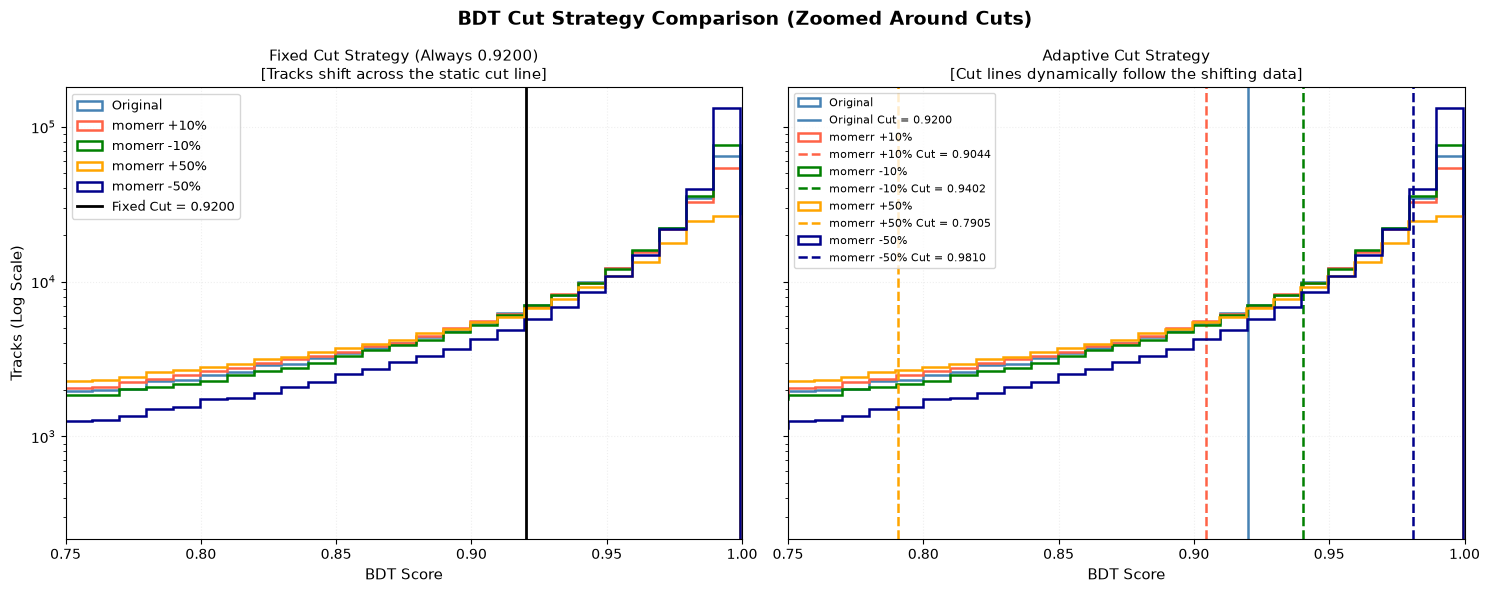


=============================== SUMMARY TABLE ===============================
     Dataset       Passing (Fixed Cut) Net Shift (Fixed)  Passing (Adapt Cut) Net Shift (Adapt) 
   momerr +10%           161,649            -12,672             171,056             -3,265      
   momerr -10%           187,636            +13,315             172,069             -2,252      
   momerr +50%           116,466            -57,855             167,759             -6,562      
   momerr -50%           241,241            +66,920             168,047             -6,274      
Net Shift = Tracks Passing (Perturbed dataset) - Tracks Passing (Original dataset)
Note: Positive shift means more tracks pass the cut compared to original, negative means fewer.


In [ ]:
# 1. FIXED: Point the loop datasets matrix straight to the uniform 317,440 track arrays
datasets = [
    (all_studies[0][1], 'Original',   'steelblue', TRKQUAL_CUT), 
    #(all_studies[1][1], 'nactive +1', 'purple',    list(optimal_cuts.values())[1]),   
    (all_studies[1][1], 'momerr +10%', 'tomato',    list(optimal_cuts.values())[1]),
    (all_studies[2][1], 'momerr -10%', 'green',     list(optimal_cuts.values())[2]),
    (all_studies[3][1], 'momerr +50%', 'orange',    list(optimal_cuts.values())[3]),
    (all_studies[4][1], 'momerr -50%', 'darkblue',  list(optimal_cuts.values())[4]),
]


orig_passing = np.sum(datasets[0][0] >= TRKQUAL_CUT)

#1. GENERATE CLEANED PLOTS 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
fig.suptitle("BDT Cut Strategy Comparison (Zoomed Around Cuts)", fontsize=14, fontweight='bold', y=0.98)

# Left Plot: Fixed Cut Strategy
ax1.set_title(f"Fixed Cut Strategy (Always {TRKQUAL_CUT:.4f})\n[Tracks shift across the static cut line]", fontsize=11)
for scores, label, color, adapt_cut in datasets:
    ax1.hist(scores, bins=100, histtype='step', linewidth=1.8, color=color, label=label)

ax1.axvline(TRKQUAL_CUT, color='black', linestyle='-', linewidth=2, label=f'Fixed Cut = {TRKQUAL_CUT:.4f}')
ax1.set_xlim(0.75, 1.0) # Clean zoom window centered around thresholds
ax1.set_yscale('log')
ax1.set_xlabel("BDT Score", fontsize=11)
ax1.set_ylabel("Tracks (Log Scale)", fontsize=11)
ax1.grid(alpha=0.2, linestyle=':')
ax1.legend(fontsize=9, loc='upper left')

# Right Plot: Adaptive Cut Strategy
ax2.set_title("Adaptive Cut Strategy\n[Cut lines dynamically follow the shifting data]", fontsize=11)
for scores, label, color, adapt_cut in datasets:
    ax2.hist(scores, bins=100, histtype='step', linewidth=1.8, color=color, label=label)
    linestyle = '-' if label == 'Original' else '--'
    ax2.axvline(adapt_cut, color=color, linestyle=linestyle, linewidth=1.8,
                label=f"{label} Cut = {adapt_cut:.4f}")

ax2.set_xlim(0.75, 1.0)
ax2.grid(alpha=0.2, linestyle=':')
ax2.set_xlabel("BDT Score", fontsize=11)
ax2.legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()

# 2. GENERATE CLEANED DATAFRAME SUMMARY 
table_data = []
for scores, label, color, adapt_cut in datasets:
    if label == 'Original': continue
    
    passing_fixed = np.sum(scores >= TRKQUAL_CUT)
    diff_fixed    = passing_fixed - orig_passing
    
    passing_adapt = np.sum(scores >= adapt_cut)
    diff_adapt    = passing_adapt - orig_passing
    
    table_data.append([
        label, 
        f"{passing_fixed:,}", f"{diff_fixed:+,}", 
        f"{passing_adapt:,}", f"{diff_adapt:+,}"
    ])

df_clean = pd.DataFrame(table_data, columns=[
    "Dataset", "Passing (Fixed Cut)", "Net Shift (Fixed)", "Passing (Adapt Cut)", "Net Shift (Adapt)"
])

print("\n" + "="*31 + " SUMMARY TABLE " + "="*31)
print(df_clean.to_string(index=False, justify='center', col_space=18))
print("="*77)
print("Net Shift = Tracks Passing (Perturbed dataset) - Tracks Passing (Original dataset)")
print("Note: Positive shift means more tracks pass the cut compared to original, negative means fewer.")


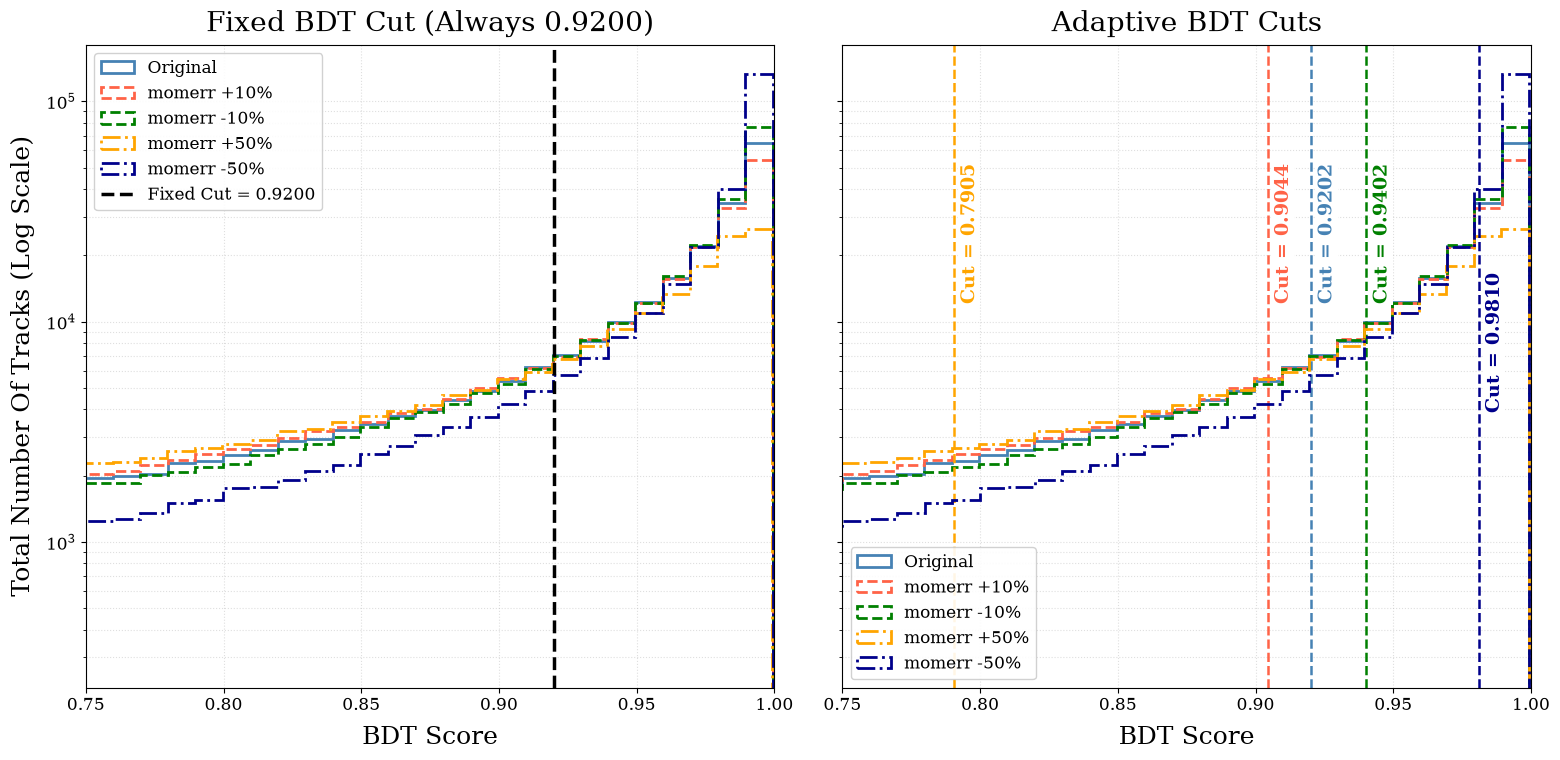

In [ ]:
# 1. Match default LaTeX font 
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['DejaVu Serif', 'Bitstream Vera Serif', 'Computer Modern Roman', 'Times New Roman']
plt.rcParams['pdf.fonttype'] = 42

# Scale font sizes up
plt.rcParams.update({
    'font.size': 20,
    'axes.labelsize': 18,
    'axes.titlesize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12
})

# 2. Establish constants
TRKQUAL_CUT = 0.92

optimal_cuts = {
    'Original': 0.9202,
    'momerr +10%': 0.9044,
    'momerr -10%': 0.9402,
    'momerr +50%': 0.7905,
    'momerr -50%': 0.9810
}

# Add unique vertical text placement values ('y_pos') to prevent label collision
plot_configs = [
    {"scores": y_pred_orig,    "label": "Original",    "color": "steelblue", "style": "-",  "y_pos": 25000, "ha": "left",  "offset": 0.002},
    {"scores": y_pred_up,      "label": "momerr +10%", "color": "tomato",    "style": "--", "y_pos": 25000, "ha": "left",  "offset": 0.002},
    {"scores": y_pred_down,    "label": "momerr -10%", "color": "green",     "style": "--", "y_pos": 25000, "ha": "left",  "offset": 0.002},
    {"scores": y_pred_up50,    "label": "momerr +50%", "color": "orange",    "style": "-.", "y_pos": 25000,  "ha": "left",  "offset": 0.002},
    {"scores": y_pred_down50,  "label": "momerr -50%", "color": "darkblue",  "style": "-.", "y_pos": 8000,  "ha": "right", "offset": -0.004}
]
# 3. Setup a clean 1x2 plotting grid canvas sharing the Y-axis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), sharey=True)
#fig.suptitle("BDT Cut Strategy Comparison (Zoomed Around Cuts)", fontsize=16, fontweight='bold', y=0.98)

# LEFT PANEL: FIXED BDT CUT 

ax1.set_title("Fixed BDT Cut (Always 0.9200)", fontsize=20, pad=10)

for cfg in plot_configs:
    ax1.hist(cfg["scores"], bins=100, histtype='step', color=cfg["color"], 
             linestyle=cfg["style"], linewidth=2.0, label=cfg["label"])

ax1.axvline(TRKQUAL_CUT, color="black", linestyle="--", linewidth=2.5, label=f"Fixed Cut = {TRKQUAL_CUT:.4f}")

ax1.set_xlim(0.75, 1.0)
ax1.set_yscale('log')
ax1.set_xlabel("BDT Score", labelpad=8)
ax1.set_ylabel("Total Number Of Tracks (Log Scale)", labelpad=8)
ax1.grid(True, which="both", linestyle=":", alpha=0.4)
ax1.legend(loc="upper left", framealpha=0.9)

# RIGHT PANEL: ADAPTIVE BDT CUT 

ax2.set_title("Adaptive BDT Cuts", fontsize=20, pad=10)

for cfg in plot_configs:
    ax2.hist(cfg["scores"], bins=100, histtype='step', color=cfg["color"], 
             linestyle=cfg["style"], linewidth=2.0, label=cfg["label"])
    
    dyn_cut = optimal_cuts[cfg["label"]]
    
    ax2.axvline(dyn_cut, color=cfg["color"], linestyle="--", linewidth=1.8)
    
    ax2.text(x=dyn_cut + 0.002, y=cfg["y_pos"], s=f"Cut = {dyn_cut:.4f}", 
             color=cfg["color"], rotation=90, va='center', ha='left',
             fontweight='bold', fontsize=14, 
             bbox=dict(facecolor='white', edgecolor='none', pad=1))

# Aesthetics for panel 2
ax2.set_xlim(0.75, 1.0)
ax2.set_xlabel("BDT Score", labelpad=8)
ax2.grid(True, which="both", linestyle=":", alpha=0.4)

ax2.legend(loc="lower left", framealpha=0.9)

plt.tight_layout()

# 4. Save fig
fig.savefig("/Users/malikfarouh/Documents/latex_notes/2026-08_TrkQual_Robustness_BDT/images/BDT_Strategy_Master_Comparison.pdf", bbox_inches="tight")
plt.show()

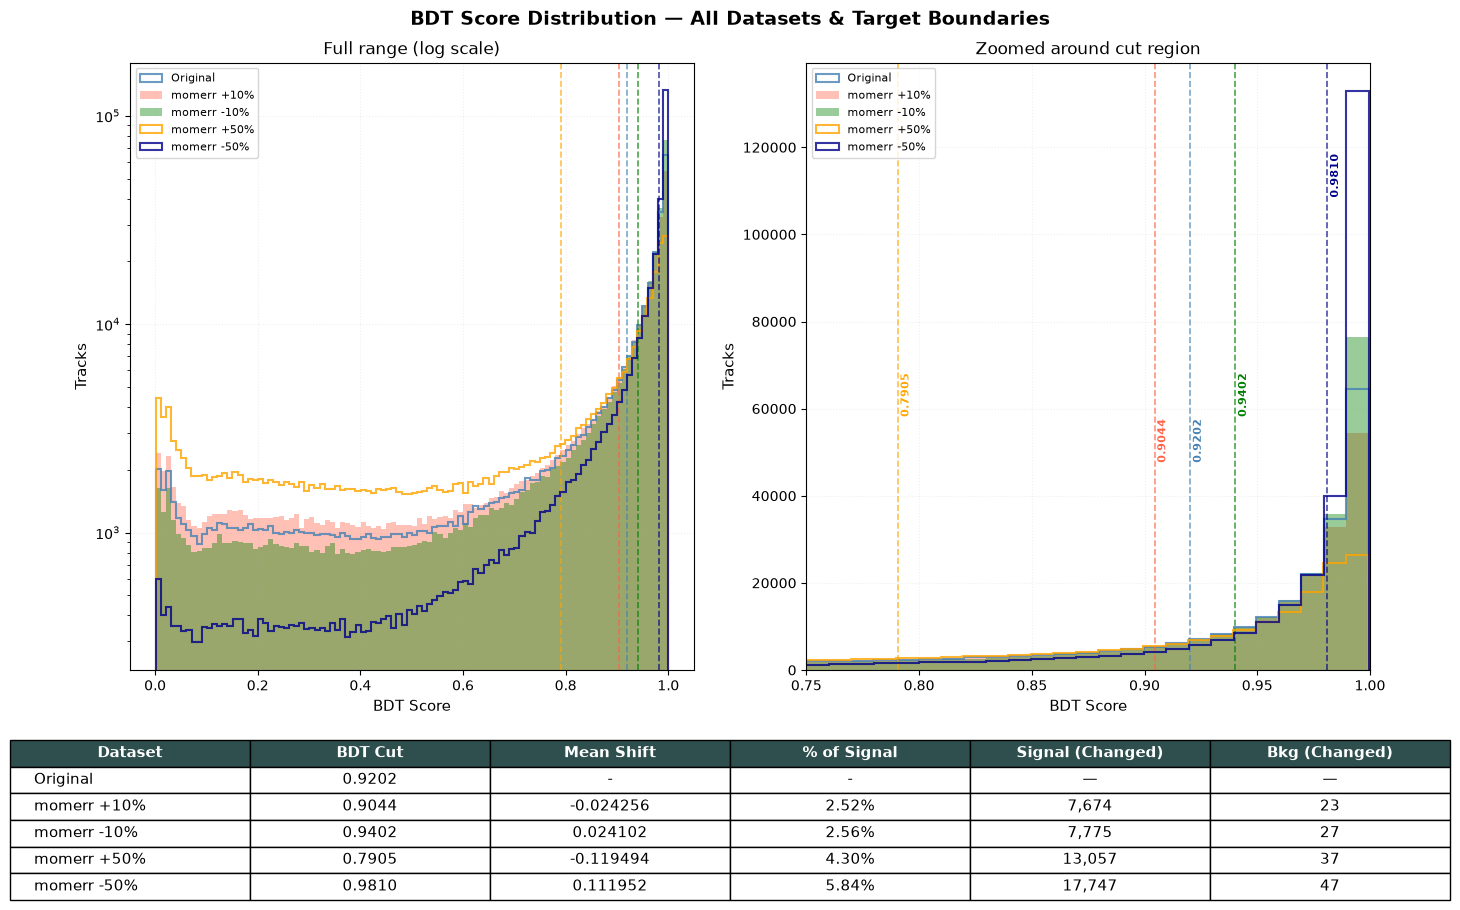

In [14]:
colors = {
    'Original': 'steelblue', 'momerr +10%': 'tomato', #''''nactive +1': 'purple','''
    'momerr -10%': 'green',  'momerr +50%': 'orange', 'momerr -50%': 'darkblue'
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7.5))
fig.suptitle("BDT Score Distribution — All Datasets & Target Boundaries", fontsize=14, fontweight='bold', y=0.95)

# 2. Renders distributions and draws labeled threshold lines
for ax, title, xlim in zip([ax1, ax2], ['Full range (log scale)', 'Zoomed around cut region'], [None, (0.75, 1.0)]):
    for label, scores in all_studies:
        htype = 'stepfilled' if '10%' in label else 'step'
        alpha = 0.4 if '10%' in label else 0.8
        ax.hist(scores, bins=100, histtype=htype, color=colors[label], alpha=alpha, linewidth=1.5, label=label)
        
        # Draw vertical lines for the adaptive cuts
        cut_val = optimal_cuts[label]
        ax.axvline(cut_val, color=colors[label], linestyle='--', linewidth=1.2, alpha=0.7)
        
        # Annotate the right-hand zoomed plot with clear numeric labels
        if ax == ax2:
            ax.text(cut_val + 0.001, ax.get_ylim()[1] * 0.85, f"{cut_val:.4f}", color=colors[label],
                    fontsize=8, rotation=90, va='top', ha='left', weight='bold')
            
    ax.set_xlabel("BDT Score", fontsize=11)
    ax.set_ylabel("Tracks", fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.grid(alpha=0.2, linestyle=':')
    ax.legend(loc='upper left', fontsize=8)
    if xlim: ax.set_xlim(xlim)
    else: ax.set_yscale('log')

# 3. Matches Cell #2 logic exactly to extract changed track counts
table_data = []
y_pred_orig = all_studies[0][1] # Establish baseline predictions 

for label, scores in all_studies:
    cut_val = optimal_cuts[label]
    
    if label == 'Original':
        mean_shift = "-"
        pct_sig = "-"
        sig_str = "—"
        bkg_str = "—"
    else:
        delta = scores - y_pred_orig
        mean_shift = f"{delta.mean():.6f}"
        
        bdt_pass_orig = y_pred_orig >= TRKQUAL_CUT
        bdt_pass_new  = scores >= cut_val
        drift_mask = bdt_pass_orig != bdt_pass_new
        
        sig_changed = ((drift_mask) & (y_full_filtered == 1)).sum()
        bkg_changed = ((drift_mask) & (y_full_filtered == 0)).sum()
        
        pct_sig = f"{(sig_changed / N_signal * 100):.2f}%"
        sig_str = f"{sig_changed:,}"
        bkg_str = f"{bkg_changed:,}"
        
    table_data.append([label, f"{cut_val:.4f}", mean_shift, pct_sig, sig_str, bkg_str])

# Embed the clean summary table block safely underneath the subplots
table_ax = fig.add_axes([0.05, -0.22, 0.9, 0.18])
table_ax.axis('off')

columns = ["Dataset", "BDT Cut", "Mean Shift", "% of Signal", "Signal (Changed)", "Bkg (Changed)"]
summary_table = table_ax.table(cellText=table_data, colLabels=columns, loc='center', cellLoc='center')
summary_table.auto_set_font_size(False)
summary_table.set_fontsize(10.5)
summary_table.scale(1.0, 1.6)

for (row, col), cell in summary_table.get_celld().items():
    if col == 0 and row > 0: cell.set_text_props(ha='left')
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#2f4f4f')

plt.subplots_adjust(bottom=0.07)
plt.show()

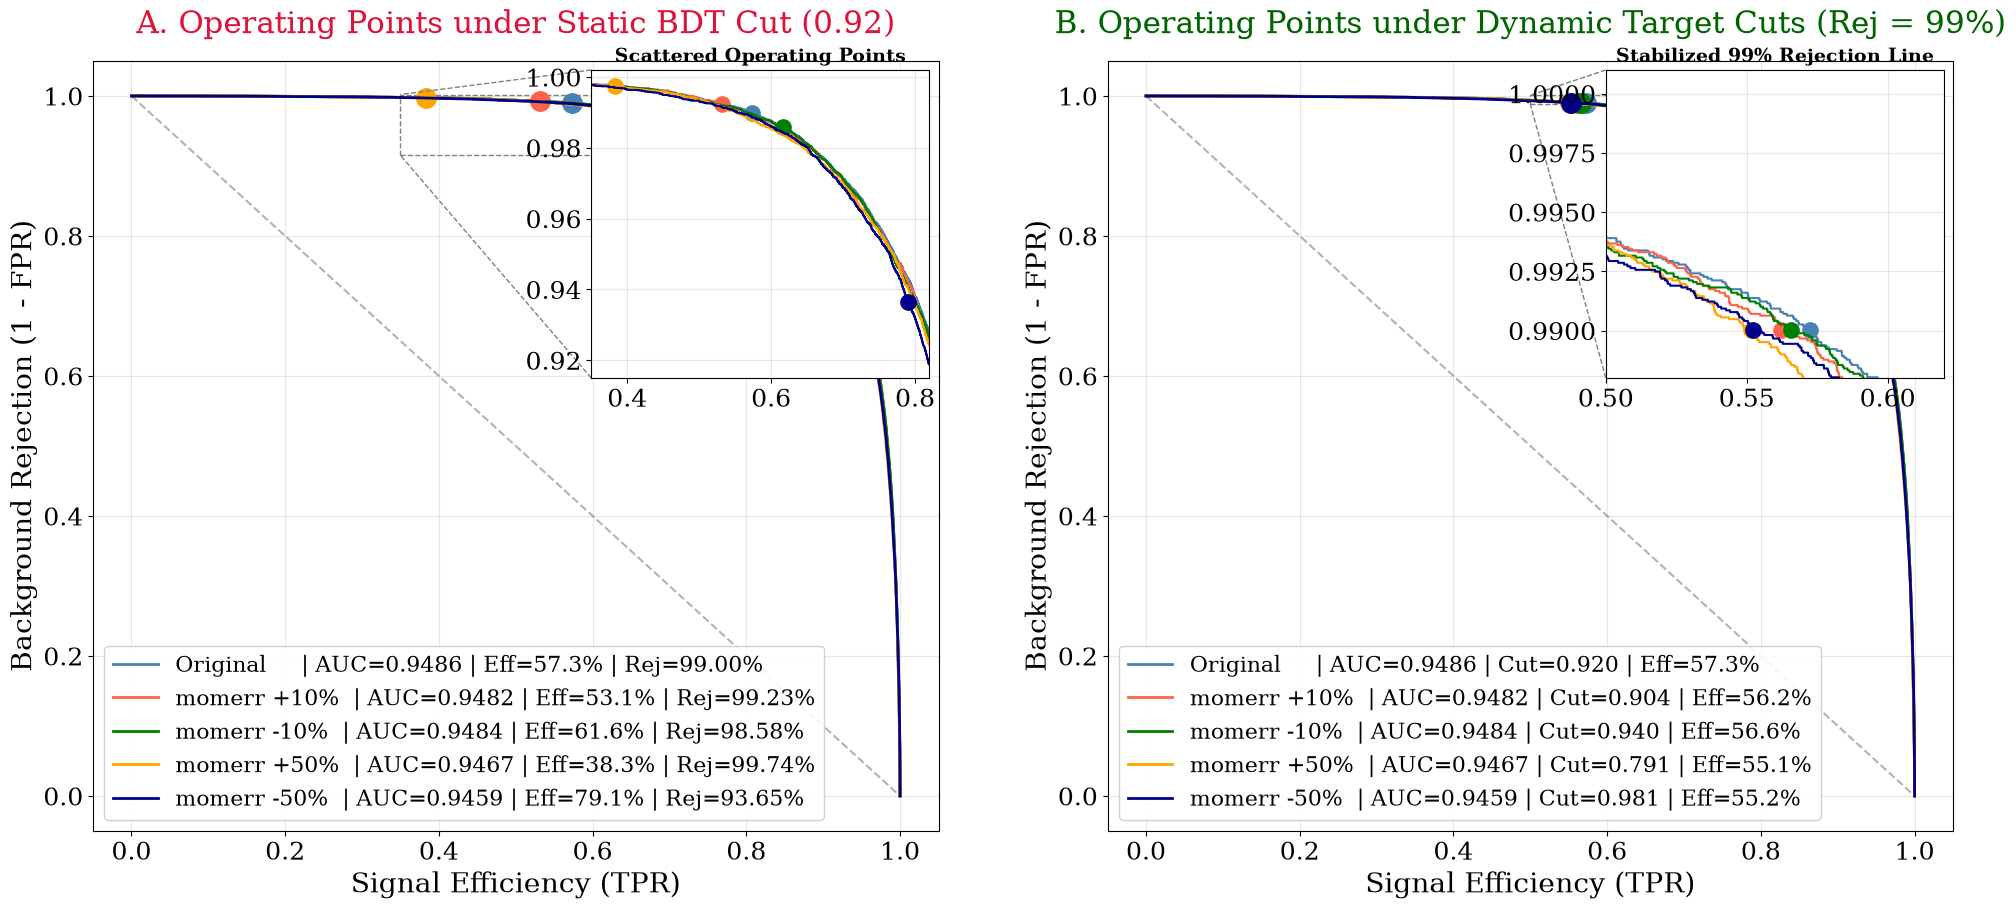

In [ ]:
# 1. Match default LaTeX font 
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['DejaVu Serif', 'Bitstream Vera Serif', 'Computer Modern Roman', 'Times New Roman']
plt.rcParams['pdf.fonttype'] = 42

# Scale font sizes up
plt.rcParams.update({
    'font.size': 20,
    'axes.labelsize': 18,
    'axes.titlesize': 14,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 13
})

# 2. Establish constants
TRKQUAL_CUT = 0.92

optimal_cuts = {
    'Original': 0.9202,
    'momerr +10%': 0.9044,
    'momerr -10%': 0.9402,
    'momerr +50%': 0.7905,
    'momerr -50%': 0.9810
}


# 1. Define dataset configurations
datasets_roc = [
    (y_pred_orig, y_full_filtered, 'Original', 'steelblue'),
    #(y_pred_perturbed_full, y_full_filtered, 'nactive +1', 'purple'),
    (y_pred_up, y_full_filtered, 'momerr +10%', 'tomato'),
    (y_pred_down, y_full_filtered, 'momerr -10%', 'green'),
    (y_pred_up50, y_full_filtered, 'momerr +50%', 'orange'),
    (y_pred_down50, y_full_filtered, 'momerr -50%', 'darkblue'),
]

static_cut_target = 0.92
rej_target = 0.99

# 2. Initialize side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 10)) # Slightly wider to prevent text squeezing
#fig.suptitle("ROC Curve Analysis: Static Cut vs. Adaptive Cut", fontsize=28, fontweight='bold', y=0.96)

# Setup shared insets for both panels.  (-0.02, -0.02, 1, 1)
ax_ins1 = inset_axes(ax1, width="40%", height="40%", loc='upper right', bbox_to_anchor=(0.0, 0.0, 1, 1), bbox_transform=ax1.transAxes)
ax_ins2 = inset_axes(ax2, width="40%", height="40%", loc='upper right', bbox_to_anchor=(0.0, 0.0, 1, 1), bbox_transform=ax2.transAxes)

# 3. Loop through data to plot Left Panel (Static Cut) and Right Panel (Dynamic Threshold)
for scores, labels, name, color in datasets_roc:
    fpr, tpr, thresholds = roc_curve(labels, scores, pos_label=1)
    auc_score = auc(fpr, tpr)
    
    # --- LEFT PANEL: STATIC CUT SELECTION ---
    indices_static = np.where(thresholds >= static_cut_target)[0]
    idx_stat = indices_static[-1] if len(indices_static) > 0 else 0 # Explicitly target the 1D index element
    sig_eff_stat = float(tpr[idx_stat])
    bkg_rej_stat = float(1 - fpr[idx_stat])
    
    # Included AUC score into the text block string format
    ax1.plot(tpr, 1 - fpr, color=color, linewidth=2, 
             label=f"{name:<12} | AUC={auc_score:.4f} | Eff={sig_eff_stat*100:.1f}% | Rej={bkg_rej_stat*100:.2f}%")
    ax1.plot(tpr[idx_stat], 1 - fpr[idx_stat], 'o', color=color, markersize=14)
    ax_ins1.plot(tpr, 1 - fpr, color=color, linewidth=1.5)
    ax_ins1.plot(tpr[idx_stat], 1 - fpr[idx_stat], 'o', color=color, markersize=11)
    
    # --- RIGHT PANEL: DYNAMIC ADAPTIVE SELECTION ---
    indices_dyn = np.where(1 - fpr >= rej_target)[0]
    idx_dyn = indices_dyn[-1] if len(indices_dyn) > 0 else 0 # Explicitly target the 1D index element
    sig_eff_dyn = float(tpr[idx_dyn])
    opt_cut = float(thresholds[idx_dyn])
    
    # Included AUC score into the text block string format
    ax2.plot(tpr, 1 - fpr, color=color, linewidth=2, 
             label=f"{name:<12} | AUC={auc_score:.4f} | Cut={opt_cut:.3f} | Eff={sig_eff_dyn*100:.1f}%")
    ax2.plot(tpr[idx_dyn], 1 - fpr[idx_dyn], 'o', color=color, markersize=14)
    ax_ins2.plot(tpr, 1 - fpr, color=color, linewidth=1.5)
    ax_ins2.plot(tpr[idx_dyn], 1 - fpr[idx_dyn], 'o', color=color, markersize=11)

# 4. Format Left Subplot (Static Cut)
ax1.plot([0, 1], [1, 0], 'k--', alpha=0.3)
ax1.set_xlabel("Signal Efficiency (TPR)", fontsize=20)
ax1.set_ylabel("Background Rejection (1 - FPR)", fontsize=20)
ax1.set_title("A. Operating Points under Static BDT Cut (0.92)", fontsize=22, color='crimson', pad=20)
ax1.grid(alpha=0.3)
ax1.legend(loc='lower left', fontsize=16, framealpha=0.9)

ax_ins1.set_xlim(0.35, 0.82)
ax_ins1.set_ylim(0.915, 1.002)
ax_ins1.set_title("Scattered Operating Points", fontsize=14, fontweight='bold')
ax_ins1.grid(alpha=0.3)
mark_inset(ax1, ax_ins1, loc1=2, loc2=3, fc="none", ec="0.5", ls="--")

# 5. Format Right Subplot (Dynamic Thresholds)
ax2.plot([0, 1], [1, 0], 'k--', alpha=0.3)
ax2.set_xlabel("Signal Efficiency (TPR)", fontsize=20)
ax2.set_ylabel("Background Rejection (1 - FPR)", fontsize=20)
ax2.set_title("B. Operating Points under Dynamic Target Cuts (Rej = 99%)", fontsize=22, color='darkgreen', pad=20)
ax2.grid(alpha=0.3)
ax2.legend(loc='lower left', fontsize=16, framealpha=0.9)

ax_ins2.set_xlim(0.50, 0.62)
ax_ins2.set_ylim(0.988, 1.001)
ax_ins2.set_title("Stabilized 99% Rejection Line", fontsize=14, fontweight='bold')
ax_ins2.grid(alpha=0.3)
mark_inset(ax2, ax_ins2, loc1=2, loc2=3, fc="none", ec="0.5", ls="--")
plt.tight_layout()
fig.savefig("/Users/malikfarouh/Documents/latex_notes/2026-08_TrkQual_Robustness_BDT/images/ROC_Analysis_Static_v_Adaptive.pdf", bbox_inches="tight")
plt.show()

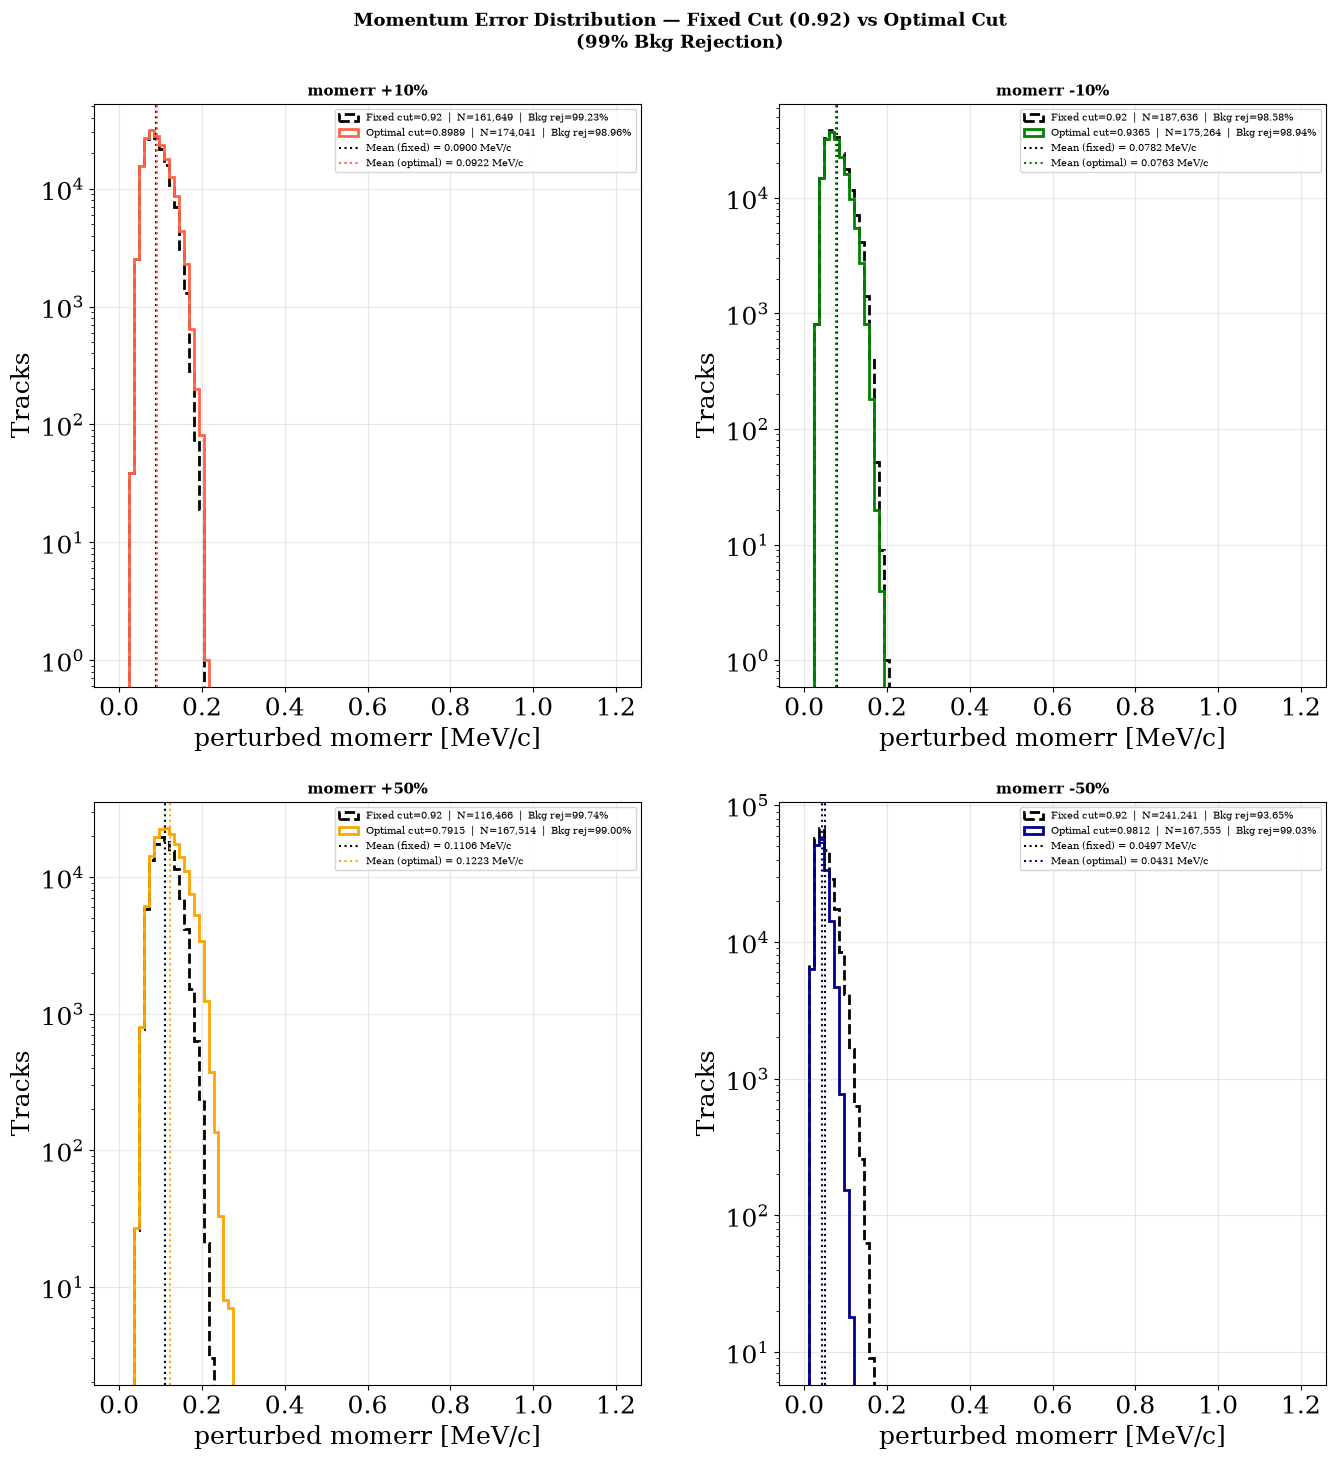

In [58]:
fig, axes = plt.subplots(2, 2, figsize=(14, 15))
fig.suptitle("Momentum Error Distribution — Fixed Cut (0.92) vs Optimal Cut\n(99% Bkg Rejection)",
             fontsize=13, fontweight='bold')

# Grabs the baseline prediction array natively from the first slot
#momerr_base = all_studies[0][1]

fixed_cut   = 0.92

studies = [
    #('nactive +1',  y_pred_perturbed_full, 0.9334, 'purple',    1.0),
    ('momerr +10%', y_pred_up,      0.8989, 'tomato',    1.1),
    ('momerr -10%', y_pred_down,    0.9365, 'green',     0.9),
    ('momerr +50%', y_pred_up50,    0.7915, 'orange',    1.5),
    ('momerr -50%', y_pred_down50,  0.9812, 'darkblue',  0.5),
]
for idx, (label, scores, opt_cut, color, factor) in enumerate(studies):
    row = idx // 2
    col = idx % 2
    ax  = axes[row, col]

    # Create the GENUINE perturbed variable for this specific panel
    momerr_perturbed = momerr_base * factor

    # Fixed cut applied to perturbed data
    mask_fixed = scores >= fixed_cut
    N_fixed    = mask_fixed.sum()
    m_fixed    = momerr_perturbed[mask_fixed].mean()
    bkg_fixed  = 1 - (((scores >= fixed_cut) & (y_full_filtered == 0)).sum() / (y_full_filtered == 0).sum())

    # Optimal cut applied to perturbed data
    mask_opt = scores >= opt_cut
    N_opt    = mask_opt.sum()
    m_opt    = momerr_perturbed[mask_opt].mean()
    bkg_opt  = 1 - (((scores >= opt_cut) & (y_full_filtered == 0)).sum() / (y_full_filtered == 0).sum())

    # Plot both overlapped using the perturbed data 
    ax.hist(momerr_perturbed[mask_fixed], bins=100, range=(0, 1.2), log=True,
            histtype='step', color='black', linewidth=2, linestyle='--',
            label=f"Fixed cut=0.92  |  N={N_fixed:,}  |  Bkg rej={bkg_fixed*100:.2f}%")
    ax.hist(momerr_perturbed[mask_opt], bins=100, range=(0, 1.2), log=True,
            histtype='step', color=color, linewidth=2, linestyle='-',
            label=f"Optimal cut={opt_cut:.4f}  |  N={N_opt:,}  |  Bkg rej={bkg_opt*100:.2f}%")

    # Mean lines mapping the real perturbed averages
    ax.axvline(m_fixed, color='black', linestyle=':', linewidth=1.5,
               label=f"Mean (fixed) = {m_fixed:.4f} MeV/c")
    ax.axvline(m_opt, color=color, linestyle=':', linewidth=1.5,
               label=f"Mean (optimal) = {m_opt:.4f} MeV/c")

    ax.set_title(f"{label}", fontsize=11, fontweight='bold')
    ax.set_xlabel("perturbed momerr [MeV/c]")
    ax.set_ylabel("Tracks")
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

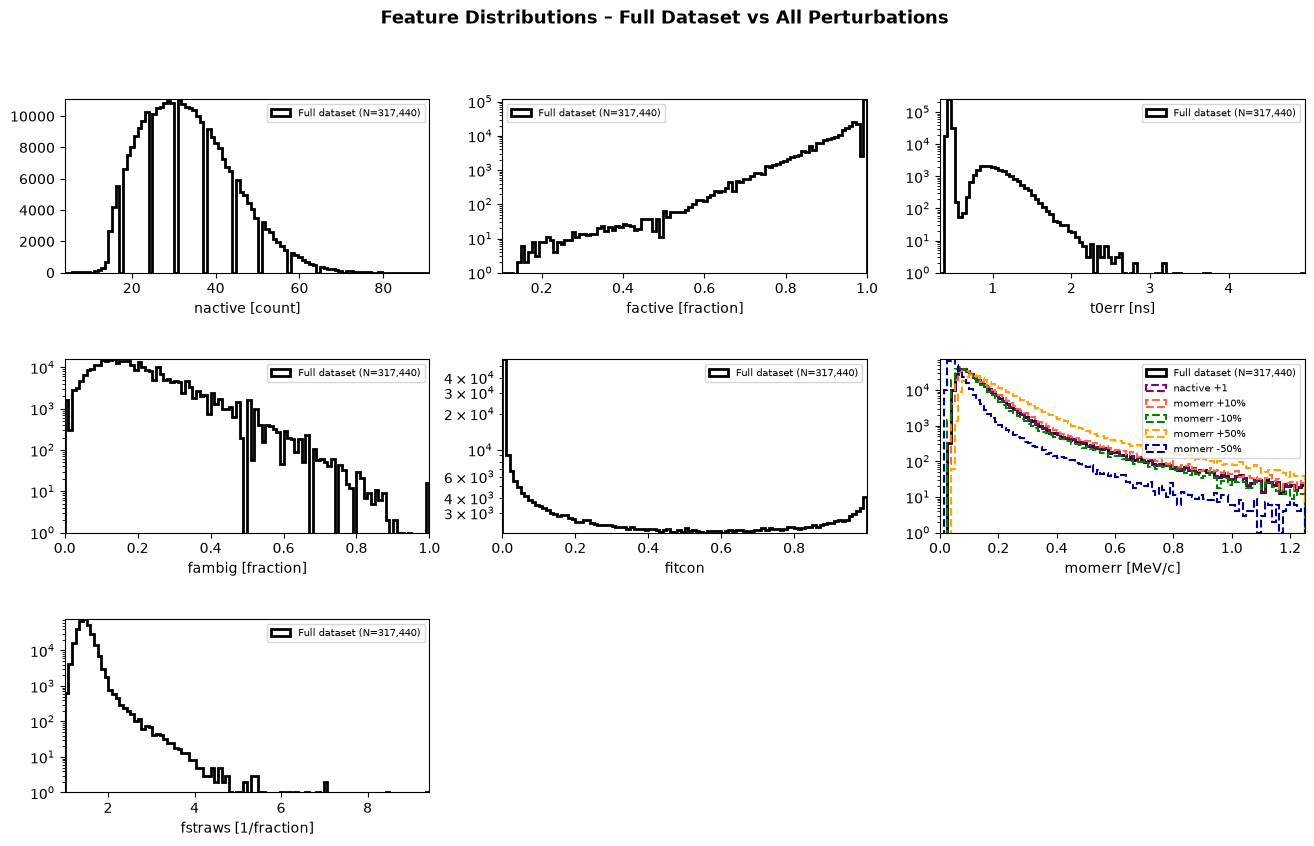

In [18]:
input_var_names = ["nactive", "factive", "t0err", "fambig", "fitcon", "momerr", "fstraws"]
n_input_vars = len(input_var_names)
momerr_idx = input_var_names.index('momerr')

# Build a list of your real raw feature arrays 
raw_features = [
    nactive_base,
    nactive_base / nhits_base, # factive
    t0err_base,
    nnull_base / nactive_base, # fambig
    fitcon_base,
    momerr_base,
    nmat_base / nactive_base   # fstraws
]

# Extract min/max boundaries directly from the true physical feature sizes 
x_mins = [float(raw_features[i].min()) for i in range(n_input_vars)]
x_maxs = [float(raw_features[i].max()) for i in range(n_input_vars)]

#the momerr zoom limits 
x_mins[momerr_idx] = 0.0
x_maxs[momerr_idx] = 1.25

units = [" [count]", " [fraction]", " [ns]", " [fraction]", "", " [MeV/c]", " [1/fraction]"]
log_ys = [False, True, True, True, True, True, True]

fig, axs = plt.subplots(3, 3, figsize=(16, 9))
fig.subplots_adjust(hspace=.5)
fig.suptitle("Feature Distributions – Full Dataset vs All Perturbations", fontsize=13, fontweight='bold')

# The original clean loop layout
for i_var in range(n_input_vars):
    ax = axs.flatten()[i_var]
    
    # Baseline control (Original dataset)
    ax.hist(raw_features[i_var], bins=100, range=(x_mins[i_var], x_maxs[i_var]),
            histtype='step', color='black', log=log_ys[i_var],
            label=f'Full dataset (N={len(y_full_filtered):,})', linewidth=2.0)
    
    # Overlay the specific perturbation streams exclusively at the momerr panel index
    if i_var == momerr_idx:
        # For nactive +1 panel overlay (this remains on the momerr chart as an impact reference)
        ax.hist(momerr_base, bins=100, range=(x_mins[i_var], x_maxs[i_var]),
                histtype='step', color='purple', log=log_ys[i_var], label='nactive +1', linestyle='--', linewidth=1.5)
        
        ax.hist(momerr_base * 1.10, bins=100, range=(x_mins[i_var], x_maxs[i_var]),
                histtype='step', color='tomato', log=log_ys[i_var], label='momerr +10%', linestyle='--', linewidth=1.5)
        
        ax.hist(momerr_base * 0.90, bins=100, range=(x_mins[i_var], x_maxs[i_var]),
                histtype='step', color='green', log=log_ys[i_var], label='momerr -10%', linestyle='--', linewidth=1.5)
        
        ax.hist(momerr_base * 1.50, bins=100, range=(x_mins[i_var], x_maxs[i_var]),
                histtype='step', color='orange', log=log_ys[i_var], label='momerr +50%', linestyle='--', linewidth=1.5)
        
        ax.hist(momerr_base * 0.50, bins=100, range=(x_mins[i_var], x_maxs[i_var]),
                histtype='step', color='darkblue', log=log_ys[i_var], label='momerr -50%', linestyle='--', linewidth=1.5)
        
    ax.set_xlabel(input_var_names[i_var] + units[i_var])
    ax.margins(0)
    ax.legend(fontsize=7)

# Clean up empty background panels
for empty_idx in range(n_input_vars, 9):
    axs.flatten()[empty_idx].axis('off')

plt.show()

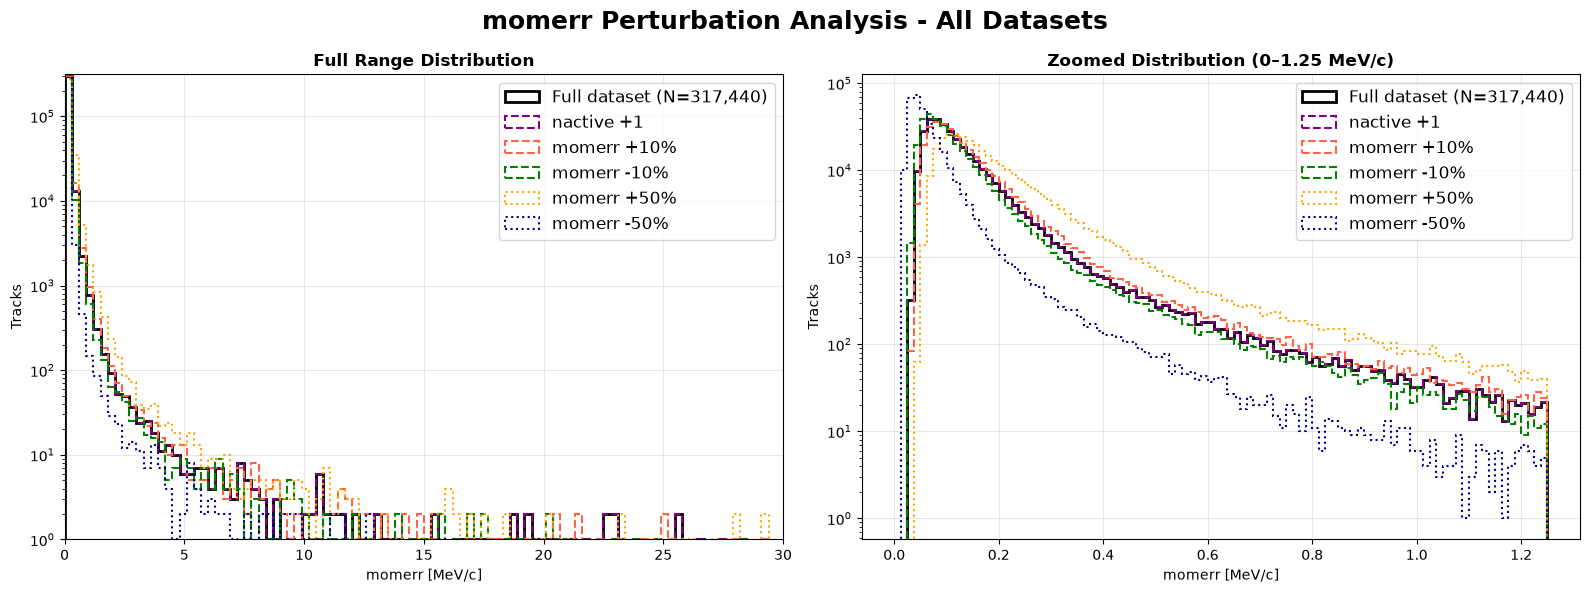

In [19]:

# 1. Setup the structural handles directly from your active variable context
i = input_var_names.index('momerr')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))


plot_params = [
    (momerr_base,        'black',    f'Full dataset (N={len(y_full_filtered):,})', '-', 2.0),
    (momerr_base,        'purple',   'nactive +1',                       '--', 1.5), # Unaltered for nactive
    (momerr_base * 1.10, 'tomato',   'momerr +10%',                      '--', 1.5),
    (momerr_base * 0.90, 'green',    'momerr -10%',                      '--', 1.5),
    (momerr_base * 1.50, 'orange',   'momerr +50%',                      ':',  1.5),
    (momerr_base * 0.50, 'darkblue', 'momerr -50%',                      ':',  1.5)
]

# Establish the real unshifted physical range boundaries natively
f_min, f_max = float(momerr_base.min()), float(momerr_base.max())

for ax in [ax1, ax2]:
    for data, color, label, style, lw in plot_params:
        
        hist_range = (0.0, 30.0) if ax == ax1 else (0.0, 1.25)
        
        ax.hist(data, bins=100, range=hist_range,
                histtype='step', color=color, log=True,
                label=label, linestyle=style, linewidth=lw)
        
    ax.set_ylabel("Tracks")
    ax.legend(fontsize=12)
    ax.grid(alpha=0.3)

# 3. Axis titles and labels customization
ax1.set_title("Full Range Distribution", fontweight='bold')
ax1.set_xlabel(f"{input_var_names[i]}{units[i]}")
ax1.margins(0)

ax2.set_title("Zoomed Distribution (0–1.25 MeV/c)", fontweight='bold')
ax2.set_xlabel("momerr [MeV/c]")

fig.suptitle("momerr Perturbation Analysis - All Datasets", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

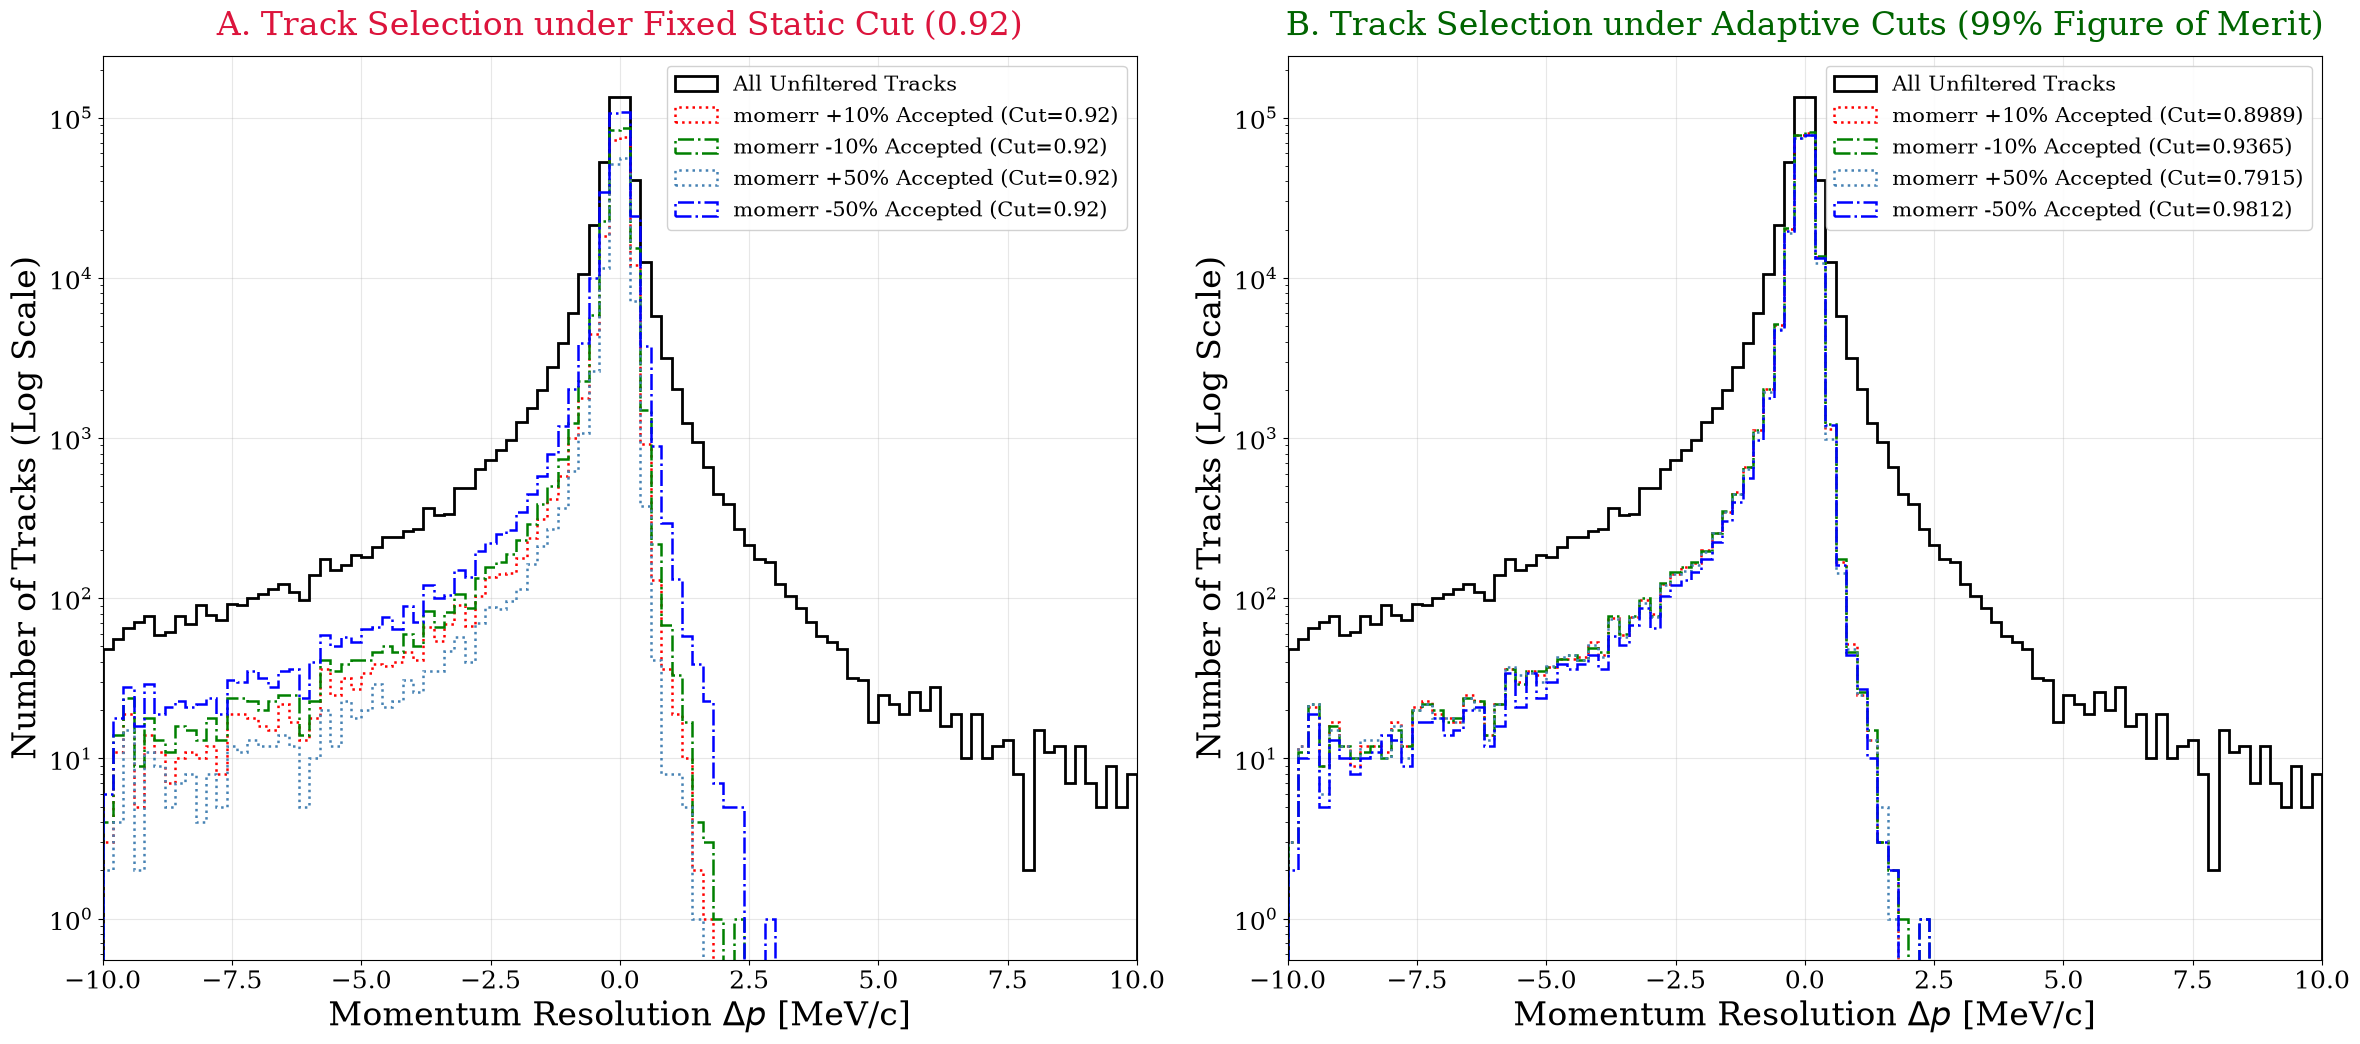

In [87]:
# 1. Configuration parameters
static_cut = 0.92
# Unique cuts calculated to maintain the constant 99% background rejection target
dynamic_cuts = {
    'momerr +10%': 0.8989,
    'momerr -10%': 0.9365,
    'momerr +50%': 0.7915,
    'momerr -50%': 0.9812,
}
# Dictionary holding dataset configurations, colors, and line styles
variations = {
    'momerr +10%': (1.10, 'red',    ':'),
    'momerr -10%': (0.90, 'green',     '-.'),
    'momerr +50%': (1.50, 'steelblue',   ':'),
    'momerr -50%': (0.50, 'blue', '-.'),
}

# 2. Extract base feature structures from the ROOT file
with uproot.open(f"{BASE_PATH}:{TREE_NAME}") as tree:
    arrays = tree.arrays(library="np")
    
    nactive = arrays['trk.nactive']
    nhits   = arrays['trk.nhits']
    factive = nactive / nhits
    fambig  = arrays['trk.nnullambig'] / nactive
    fstraws = arrays['trk.nmatactive'] / nactive
    t0err   = arrays['trk_ent_pars.t0err']
    fitcon  = arrays['trk.fitcon']
    momerr_raw = arrays['trk_ent.momerr']

# 3. Initialize side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 14))
#fig.suptitle("Momentum Resolution Analysis: Static vs. Dynamic BDT Cut", fontsize=28, fontweight='bold')
# Loop through both axes to plot the background baseline first
for ax in [ax1, ax2]:
    n_mom_res_bins = 100
    min_mom_res = -10.0  # bin range matches the plotted xlim, not mom_res.min()/max()
    max_mom_res = 10.0   #  prevents outliers outside ±10 from stretching the bin width
    
    ax.hist(mom_res, bins=n_mom_res_bins, range=(min_mom_res, max_mom_res), log=True,
            histtype='step', color='black', linewidth=2.0, label='All Unfiltered Tracks')
# 4. Generate scores and overlay filtered distributions for both panels simultaneously
for name, (scale_factor, color, linestyle) in variations.items():
    # Scale momerr by its corresponding perturbation factor
    perturbed_momerr = momerr_raw * scale_factor
    
    # Restructure 2D array and compute BDT scores across the full native track sequence
    x_matrix = np.vstack((nactive, factive, t0err, fambig, fitcon, perturbed_momerr, fstraws)).T
    scores = model.predict_proba(x_matrix)[:, 1]
    
    # PANEL A: FIXED STATIC CUT SELECTION 
    passed_static = mom_res[scores >= static_cut]
    ax1.hist(passed_static, bins=n_mom_res_bins, range=(min_mom_res, max_mom_res), log=True, 
             histtype='step', color=color, linestyle=linestyle, linewidth=1.8,
             label=f'{name} Accepted (Cut={static_cut})')
    
    #  PANEL B: ADAPTIVE DYNAMIC CUT SELECTION 
    target_cut = dynamic_cuts[name]
    passed_dynamic = mom_res[scores >= target_cut]
    ax2.hist(passed_dynamic, bins=n_mom_res_bins, range=(min_mom_res, max_mom_res), log=True, 
             histtype='step', color=color, linestyle=linestyle, linewidth=1.8,
             label=f'{name} Accepted (Cut={target_cut:.4f})')
    
# 5. Format Subplot Panel A (Static Selection)
ax1.set_xlim(-10.0, 10.0)
ax1.set_xlabel("Momentum Resolution $\Delta p$ [MeV/c]", fontsize=24)
ax1.set_ylabel("Number of Tracks (Log Scale)", fontsize=24)
ax1.set_title("A. Track Selection under Fixed Static Cut (0.92)", fontsize=24, color='crimson', pad =15)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right', fontsize=15, framealpha=0.9)

# 6. Format Subplot Panel B (Dynamic Selection)
ax2.set_xlim(-10.0, 10.0)
ax2.set_xlabel("Momentum Resolution $\Delta p$ [MeV/c]", fontsize=24)
ax2.set_ylabel("Number of Tracks (Log Scale)", fontsize=24)
ax2.set_title("B. Track Selection under Adaptive Cuts (99% Figure of Merit)", fontsize=24, color='darkgreen', pad = 15)
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper right', fontsize=15, framealpha=0.9)

plt.tight_layout()
plt.subplots_adjust(bottom=0.30)
fig.savefig("/Users/malikfarouh/Documents/latex_notes/2026-08_TrkQual_Robustness_BDT/images/MomRes_Static_v_Dynamic_Comparison.pdf", bbox_inches="tight")
plt.show()

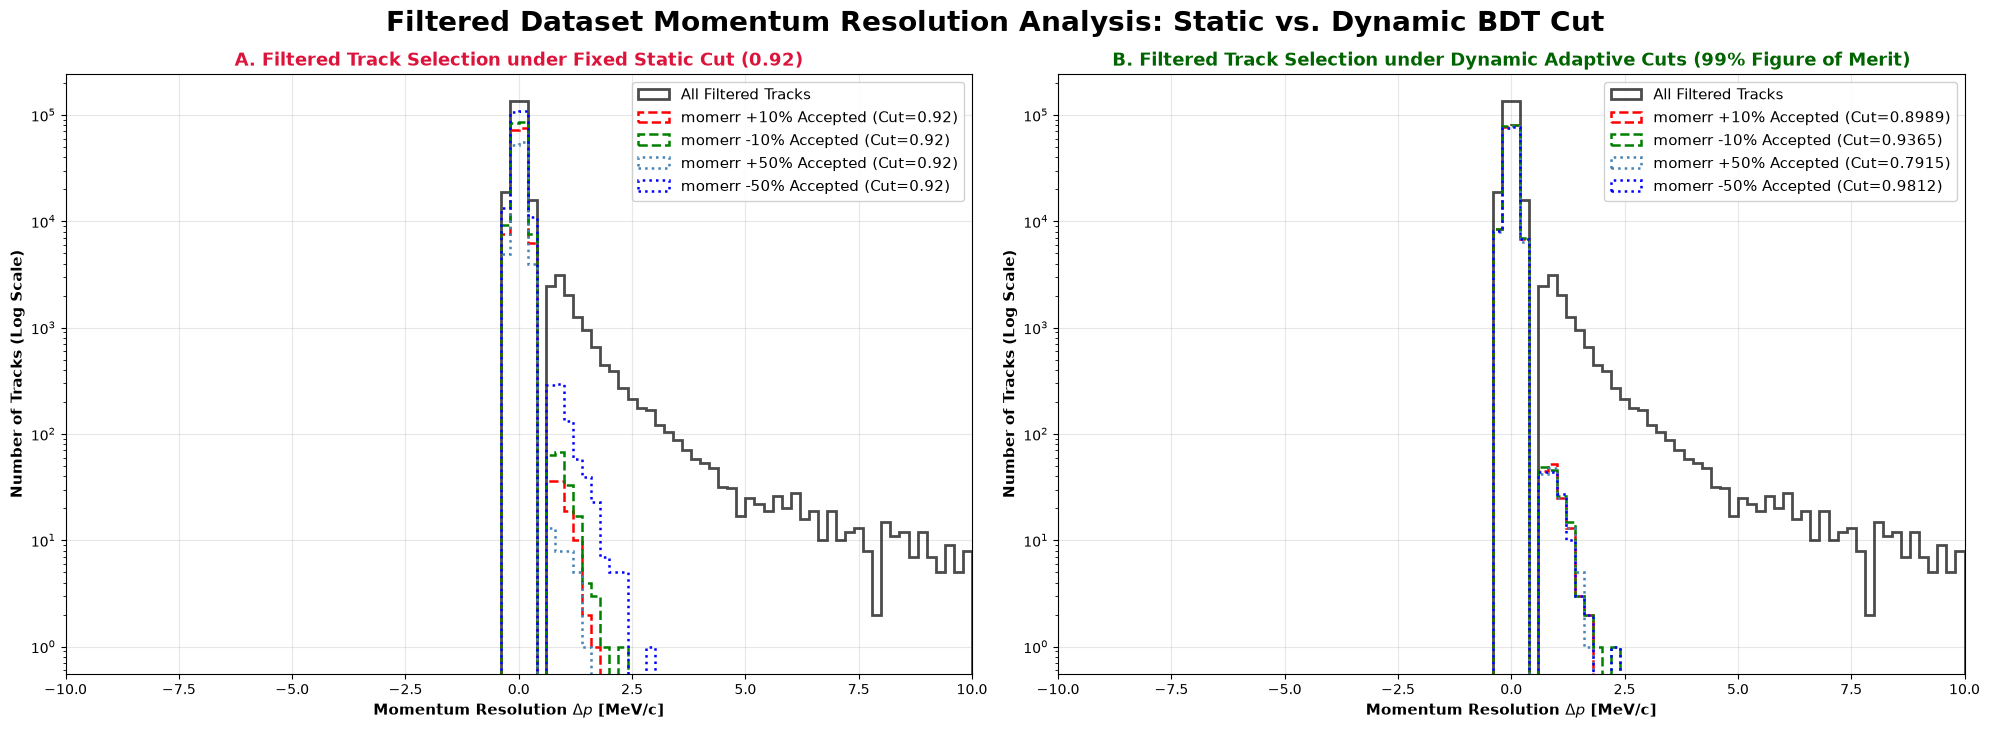

In [21]:
# 1. Configuration parameters
static_cut = 0.92
dynamic_cuts = {
    'momerr +10%': 0.8989,
    'momerr -10%': 0.9365,
    'momerr +50%': 0.7915,
    'momerr -50%': 0.9812
}

variations = {
    'momerr +10%': (1.10, 'red',      '--'),
    'momerr -10%': (0.90, 'green',    '--'),
    'momerr +50%': (1.50, 'steelblue', ':'),
    'momerr -50%': (0.50, 'blue',      ':')
}

# 2. Initialize side-by-side subplots grid canvas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle("Filtered Dataset Momentum Resolution Analysis: Static vs. Dynamic BDT Cut", fontsize=20, fontweight='bold')

n_mom_res_bins = 100
min_mom_res = -10.0
max_mom_res = 10.0


mom_res_filtered = mom_res[mask] #from cell #1

# 3. Draw the clean, isolated total filtered background baseline on both panels
for ax in [ax1, ax2]:
    ax.hist(mom_res_filtered, bins=n_mom_res_bins, range=(min_mom_res, max_mom_res), log=True,
            histtype='step', color='black', label='All Filtered Tracks', linewidth=2.0, alpha=0.7)

# 4. Compute and overlay the filtered selections dynamically
for name, (scale_factor, color, linestyle) in variations.items():
    # Evaluate scores using the active baseline tracking arrays and helper function
    scores = evaluate_perturbed_stream(nactive_base, momerr_base * scale_factor)
    
    # PANEL A: FIXED STATIC CUT SELECTION
    passed_static = mom_res_filtered[scores >= static_cut]
    ax1.hist(passed_static, bins=n_mom_res_bins, range=(min_mom_res, max_mom_res), log=True,
             histtype='step', color=color, linestyle=linestyle, linewidth=1.8,
             label=f'{name} Accepted (Cut={static_cut})')
    
    # PANEL B: ADAPTIVE DYNAMIC CUT SELECTION
    target_cut = dynamic_cuts[name]
    passed_dynamic = mom_res_filtered[scores >= target_cut]
    ax2.hist(passed_dynamic, bins=n_mom_res_bins, range=(min_mom_res, max_mom_res), log=True,
             histtype='step', color=color, linestyle=linestyle, linewidth=1.8,
             label=f'{name} Accepted (Cut={target_cut:.4f})')

# 5. Format Subplot Panel A (Static Selection)
ax1.set_xlim(-10.0, 10.0)
ax1.set_xlabel("Momentum Resolution $\Delta p$ [MeV/c]", fontweight='bold', fontsize=11)
ax1.set_ylabel("Number of Tracks (Log Scale)", fontweight='bold', fontsize=11)
ax1.set_title("A. Filtered Track Selection under Fixed Static Cut (0.92)", fontsize=13, fontweight='bold', color='crimson')
ax1.grid(alpha=0.3)
ax1.legend(loc='upper right', fontsize=11, framealpha=0.9)

# 6. Format Subplot Panel B (Dynamic Selection)
ax2.set_xlim(-10.0, 10.0)
ax2.set_xlabel("Momentum Resolution $\Delta p$ [MeV/c]", fontweight='bold', fontsize=11)
ax2.set_ylabel("Number of Tracks (Log Scale)", fontweight='bold', fontsize=11)
ax2.set_title("B. Filtered Track Selection under Dynamic Adaptive Cuts (99% Figure of Merit)", fontsize=13, fontweight='bold', color='darkgreen')
ax2.grid(alpha=0.3)
ax2.legend(loc='upper right', fontsize=11, framealpha=0.9)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()